In [1]:
import matplotlib.pyplot as plt
import os
import torch
from torch_geometric.datasets import TUDataset
import numpy as np

import sys
sys.path.append('/root/Codes/graph-mph0/build')
import abmph
from sklearn.decomposition import PCA
from icecream import ic

dataset = TUDataset(root='../data/TUDataset', name='MUTAG')

print()
print(f'Dataset: {dataset}:')
print('====================')
print(f'Number of graphs: {len(dataset)}')
print(f'Number of features: {dataset.num_features}')
print(f'Number of classes: {dataset.num_classes}')

data = dataset[0]  # Get the first graph object.

print()
print(data)
print('=============================================================')

# Gather some statistics about the first graph.
print(f'Number of nodes: {data.num_nodes}')
print(f'Number of edges: {data.num_edges}')
print(f'Average node degree: {data.num_edges / data.num_nodes:.2f}')
print(f'Has isolated nodes: {data.has_isolated_nodes()}')
print(f'Has self-loops: {data.has_self_loops()}')
print(f'Is undirected: {data.is_undirected()}')


Dataset: MUTAG(188):
Number of graphs: 188
Number of features: 7
Number of classes: 2

Data(edge_index=[2, 38], x=[17, 7], edge_attr=[38, 4], y=[1])
Number of nodes: 17
Number of edges: 38
Average node degree: 2.24
Has isolated nodes: False
Has self-loops: False
Is undirected: True


In [2]:
# There are several ways to generate 2D edge_features
# 1. node features -> edge_features -> Dimension Reduction to 2 (PCA)
# 2. Downsize node_features dim to 2 -> for each node sum over two 
def incidence_matrix(edges, num_nodes, undirected):
    # Number of edges
    num_edges = edges.size(1)
    
    # Initialize the incidence matrix (num_nodes x num_edges)
    incidence = np.zeros((num_edges, num_nodes), dtype=np.float64)
    
    # Fill the incidence matrix
    for i in range(num_edges):
        u, v = edges[:, i]  # Get the nodes (u, v) for the i-th edge
        incidence[i, u] = 1   # Set 1 for the starting node of the edge
        if undirected:
            incidence[i, v] = 1  # Set -1 for the ending node of the edge
        else:
            incidence[i, v] = -1

    return incidence

inc_mat = incidence_matrix(data['edge_index'], data.num_nodes, 
                                 undirected = data.is_undirected())
print(inc_mat.shape)

(38, 17)


In [3]:
import numpy as np
from sklearn import datasets
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [4]:
def compute_abs_mph0(input_graph):
    # set graph features
    n_nodes = input_graph.num_nodes
    nodes = np.arange(0, n_nodes, dtype=int)
    edges = input_graph['edge_index'].reshape(-1, 2).numpy()
    node_features = np.zeros(shape=(n_nodes, 2), dtype = np.float64)
    
    # node_features = pca.fit_transform(input_graph['x']).astype(np.float64)
    pca = PCA(n_components=2)
    inc_mat = incidence_matrix(input_graph['edge_index'], input_graph.num_nodes, 
                                 undirected = input_graph.is_undirected())
    
    node_2_edge_features = inc_mat @ input_graph['x'].numpy()
    edge_feat_high_dim = np.concatenate([node_2_edge_features, input_graph['edge_attr'].numpy()], axis = 1)
    edge_features = pca.fit_transform(edge_feat_high_dim).astype(np.float64)


    # Create the Graph object
    mph_g = abmph.Graph(nodes, node_features, edges, edge_features)
    res = abmph.compute_MPH0_DTree(mph_g) 
    return res

# compute_abs_mph0(dataset[0])

In [5]:
def safe_concatenate(arr1, arr2):
    """
    Safely concatenate two 2D arrays, handling the case where one or both might be empty.
    """
    # Check if either array is empty
    if arr1.size == 0:
        return arr2  # Return arr2 if arr1 is empty
    elif arr2.size == 0:
        return arr1  # Return arr1 if arr2 is empty
    else:
        return np.concatenate((arr1, arr2), axis=0) 

In [6]:
# compute absolute mph0 and store them in arries
bettis= []
labels = []

initial_center = compute_abs_mph0(dataset[0])['b_1'][0]
x_min, y_min = initial_center
x_max, y_max = initial_center

for i, graph in enumerate(dataset):
    labels.append(graph['y'].item())
    abs_res = compute_abs_mph0(graph)
    b_1_arr = np.array(abs_res['b_1'])
    b_2_arr = np.array(abs_res['b_2'])
    bettis.append([b_1_arr, b_2_arr])

    # Update min and max for x and y
    b_arr = safe_concatenate(b_1_arr, b_2_arr)
    if len(b_arr) == 0:
        continue
    x_min = min(x_min, np.min(b_arr[:, 0]))
    x_max = max(x_max, np.max(b_arr[:, 0]))
    y_min = min(y_min, np.min(b_arr[:, 1]))
    y_max = max(y_max, np.max(b_arr[:, 1]))
    if x_max > 1e5 or y_max > 1e5 or y_min < -1e5:
        print(i)
        print(x_max)
        print(y_max)
        print(y_min)
        break

labels = np.array(labels)

[-4.123462942300936, 2.9397206593511536] [-2.6411547298651907, 2.3138480022073638]


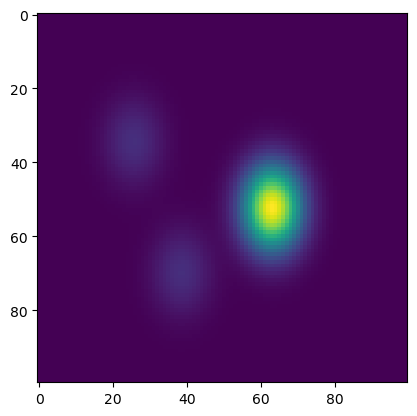

In [8]:
from gauss import determine_grid_range, sum_gaussians
imgs = []
sigma = 0.4  # Spread of the Gaussian
m = 100  # Size of the matrix
expansion_factor  = 0.4

# Determine the grid range automatically
x_range, y_range = determine_grid_range(x_min, y_min, 
                                        x_max, y_max,
                                        expansion_factor)
print(x_range, y_range)
centers = bettis[0][0]
Z = sum_gaussians(centers, x_range, y_range, sigma, m)
plt.imshow(Z)
for b_1, b_2 in bettis:
    centers1 = b_1
    centers2 = b_2
    # Compute the sum of Gaussians with automatic grid range determination
    Z1 = sum_gaussians(centers1, x_range, y_range, sigma, m)
    Z2 = sum_gaussians(centers2, x_range, y_range, sigma, m)
    imgs.append(Z1-Z2)

imgs_array = np.array([img.flatten() for img in imgs])

In [9]:
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_validate
from sklearn.metrics import make_scorer, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification

X, y = imgs_array, labels
# Define model
model = RandomForestClassifier(random_state=42)

# Define Stratified K-Fold cross-validator
skf = StratifiedKFold(n_splits=10)

# Define the scoring metrics
scoring = {
    'accuracy': 'accuracy',
    'roc_auc': 'roc_auc'
}

# Perform 10-fold cross-validation
results = cross_validate(model, X, y, cv=skf, scoring=scoring)

# Report results
print("Accuracy for each fold: ", results['test_accuracy'])
print("Mean Accuracy: ", results['test_accuracy'].mean())
print("ROC-AUC for each fold: ", results['test_roc_auc'])
print("Mean ROC-AUC: ", results['test_roc_auc'].mean())

Accuracy for each fold:  [0.94736842 1.         0.89473684 0.78947368 0.73684211 0.84210526
 0.89473684 0.84210526 0.94444444 0.72222222]
Mean Accuracy:  0.8614035087719298
ROC-AUC for each fold:  [0.98717949 1.         0.98717949 0.94871795 0.84615385 0.82738095
 0.94642857 0.83928571 1.         0.74305556]
Mean ROC-AUC:  0.9125381562881563


In [10]:
from sklearn.linear_model import LogisticRegression
LR_model = LogisticRegression()
# Define Stratified K-Fold cross-validator
skf = StratifiedKFold(n_splits=10)

# Define the scoring metrics
scoring = {
    'accuracy': 'accuracy',
    'roc_auc': 'roc_auc'
}

# Perform 10-fold cross-validation
results = cross_validate(LR_model, X, y, cv=skf, scoring=scoring)

# Report results
print("Accuracy for each fold: ", results['test_accuracy'])
print("Mean Accuracy: ", results['test_accuracy'].mean())
print("ROC-AUC for each fold: ", results['test_roc_auc'])
print("Mean ROC-AUC: ", results['test_roc_auc'].mean())

/root/miniconda3/envs/pyg/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/root/miniconda3/envs/pyg/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logis

Accuracy for each fold:  [0.94736842 0.78947368 0.68421053 0.73684211 0.73684211 0.84210526
 0.94736842 0.63157895 0.88888889 0.66666667]
Mean Accuracy:  0.7871345029239767
ROC-AUC for each fold:  [1.         0.88461538 0.85897436 0.79487179 0.62820513 0.97619048
 0.92857143 0.79761905 0.94444444 0.70833333]
Mean ROC-AUC:  0.8521825396825398


/root/miniconda3/envs/pyg/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
